In [1]:
import pandas as pd
import networkx as nx
from typing import Dict, List

# =============================================
# 1. Define Extended Ontology Schema (PrimeKG-style)
# =============================================
NODE_TYPES = {
    "gene": "Entrez Gene ID",
    "disease": "MONDO ID",
    "drug": "DrugBank ID",
    "pathway": "Reactome ID",
    "biological_process": "GO BP ID",
    "molecular_function": "GO MF ID",
    "cellular_component": "GO CC ID",
    "phenotype": "HPO ID",
    "anatomy": "UBERON ID",
    "exposure": "MeSH ID"
}

RELATION_TYPES = [
    "gene-disease-association", "drug-disease-indication", "drug-gene-target",
    "gene-pathway-participation", "gene-biological_process", "gene-molecular_function",
    "gene-cellular_component", "disease-phenotype", "disease-anatomy",
    "phenotype-phenotype-hierarchy", "pathway-pathway-hierarchy"
]

# =============================================
# 2. Sample Data (replace with real CSV/JSON from ontologies)
# =============================================
# In real PrimeKG these come from processing scripts (mondo.py, go.py, drugbank_*.py, etc.)
nodes_data = [
    # Genes
    {"node_id": "ENTREZ:673", "node_type": "gene", "node_name": "BRCA1", "node_source": "Entrez"},
    {"node_id": "ENTREZ:675", "node_type": "gene", "node_name": "BRCA2", "node_source": "Entrez"},
    # Diseases (MONDO backbone)
    {"node_id": "MONDO:0005148", "node_type": "disease", "node_name": "Breast Cancer", "node_source": "MONDO"},
    {"node_id": "MONDO:0007254", "node_type": "disease", "node_name": "Ovarian Cancer", "node_source": "MONDO"},
    # Drugs
    {"node_id": "DB00007", "node_type": "drug", "node_name": "Leuprolide", "node_source": "DrugBank"},
    # GO terms (extended ontology)
    {"node_id": "GO:0006915", "node_type": "biological_process", "node_name": "Apoptotic Process", "node_source": "GO"},
    # Phenotypes
    {"node_id": "HP:0003002", "node_type": "phenotype", "node_name": "Breast Carcinoma", "node_source": "HPO"},
]

edges_data = [
    # Gene-Disease
    {"x_id": "ENTREZ:673", "y_id": "MONDO:0005148", "relation": "gene-disease-association"},
    {"x_id": "ENTREZ:675", "y_id": "MONDO:0005148", "relation": "gene-disease-association"},
    # Drug-Disease
    {"x_id": "DB00007", "y_id": "MONDO:0005148", "relation": "drug-disease-indication"},
    # Gene-Pathway & GO (ontology extension)
    {"x_id": "ENTREZ:673", "y_id": "GO:0006915", "relation": "gene-biological_process"},
    # Disease-Phenotype
    {"x_id": "MONDO:0005148", "y_id": "HP:0003002", "relation": "disease-phenotype"},
]

# =============================================
# 3. Build Nodes & Edges DataFrames (PrimeKG exact format)
# =============================================
nodes_df = pd.DataFrame(nodes_data)
nodes_df.insert(0, "node_index", range(len(nodes_df)))  # unique integer index
nodes_df = nodes_df[["node_index", "node_id", "node_type", "node_name", "node_source"]]

edges_df = pd.DataFrame(edges_data)
# Map IDs to indices (harmonization step)
node_id_to_index = dict(zip(nodes_df["node_id"], nodes_df["node_index"]))
edges_df["x_index"] = edges_df["x_id"].map(node_id_to_index)
edges_df["y_index"] = edges_df["y_id"].map(node_id_to_index)
edges_df = edges_df[["x_index", "y_index", "relation"]].dropna()  # clean

# Add reverse edges (undirected KG, as in PrimeKG)
reverse_edges = edges_df.copy()
reverse_edges = reverse_edges.rename(columns={"x_index": "y_index", "y_index": "x_index"})
edges_df = pd.concat([edges_df, reverse_edges], ignore_index=True).drop_duplicates()

print("✅ Nodes shape:", nodes_df.shape)
print("✅ Edges shape:", edges_df.shape)
print(nodes_df.head())
print(edges_df.head())

# Save exactly like PrimeKG
nodes_df.to_csv("nodes.csv", index=False)
edges_df.to_csv("edges.csv", index=False)

# =============================================
# 4. Load into NetworkX Graph (for queries / visualization)
# =============================================
G = nx.MultiDiGraph()
for _, row in nodes_df.iterrows():
    G.add_node(row["node_index"],
               node_id=row["node_id"],
               node_type=row["node_type"],
               name=row["node_name"])

for _, row in edges_df.iterrows():
    G.add_edge(row["x_index"], row["y_index"], relation=row["relation"])

# Example query (common in biomedical KG analysis)
print("\n🔍 Example: Neighbors of Breast Cancer (MONDO:0005148)")
breast_cancer_idx = nodes_df[nodes_df["node_id"] == "MONDO:0005148"]["node_index"].iloc[0]
print([ (nodes_df.loc[nodes_df["node_index"] == n, "node_name"].iloc[0],
         G.get_edge_data(breast_cancer_idx, n)[0]["relation"])
        for n in G.neighbors(breast_cancer_idx) ])

# =============================================
# 5. Optional: Multimodal Feature Augmentation (PrimeKG style)
# =============================================
# In full pipeline you would join DrugBank JSON / Mayo Clinic text here
feature_example = {
    "MONDO:0005148": {
        "description": "Malignant tumor of the breast (from MONDO + Mayo Clinic)",
        "prevalence": "1 in 8 women",
        "risk_factors": "BRCA1/2 mutations"
    }
}
print("\n📝 Multimodal feature example attached to disease node.")

✅ Nodes shape: (7, 5)
✅ Edges shape: (10, 3)
   node_index        node_id node_type       node_name node_source
0           0     ENTREZ:673      gene           BRCA1      Entrez
1           1     ENTREZ:675      gene           BRCA2      Entrez
2           2  MONDO:0005148   disease   Breast Cancer       MONDO
3           3  MONDO:0007254   disease  Ovarian Cancer       MONDO
4           4        DB00007      drug      Leuprolide    DrugBank
   x_index  y_index                  relation
0        0        2  gene-disease-association
1        1        2  gene-disease-association
2        4        2   drug-disease-indication
3        0        5   gene-biological_process
4        2        6         disease-phenotype

🔍 Example: Neighbors of Breast Cancer (MONDO:0005148)
[('Breast Carcinoma', 'disease-phenotype'), ('BRCA1', 'gene-disease-association'), ('BRCA2', 'gene-disease-association'), ('Leuprolide', 'drug-disease-indication')]

📝 Multimodal feature example attached to disease node.


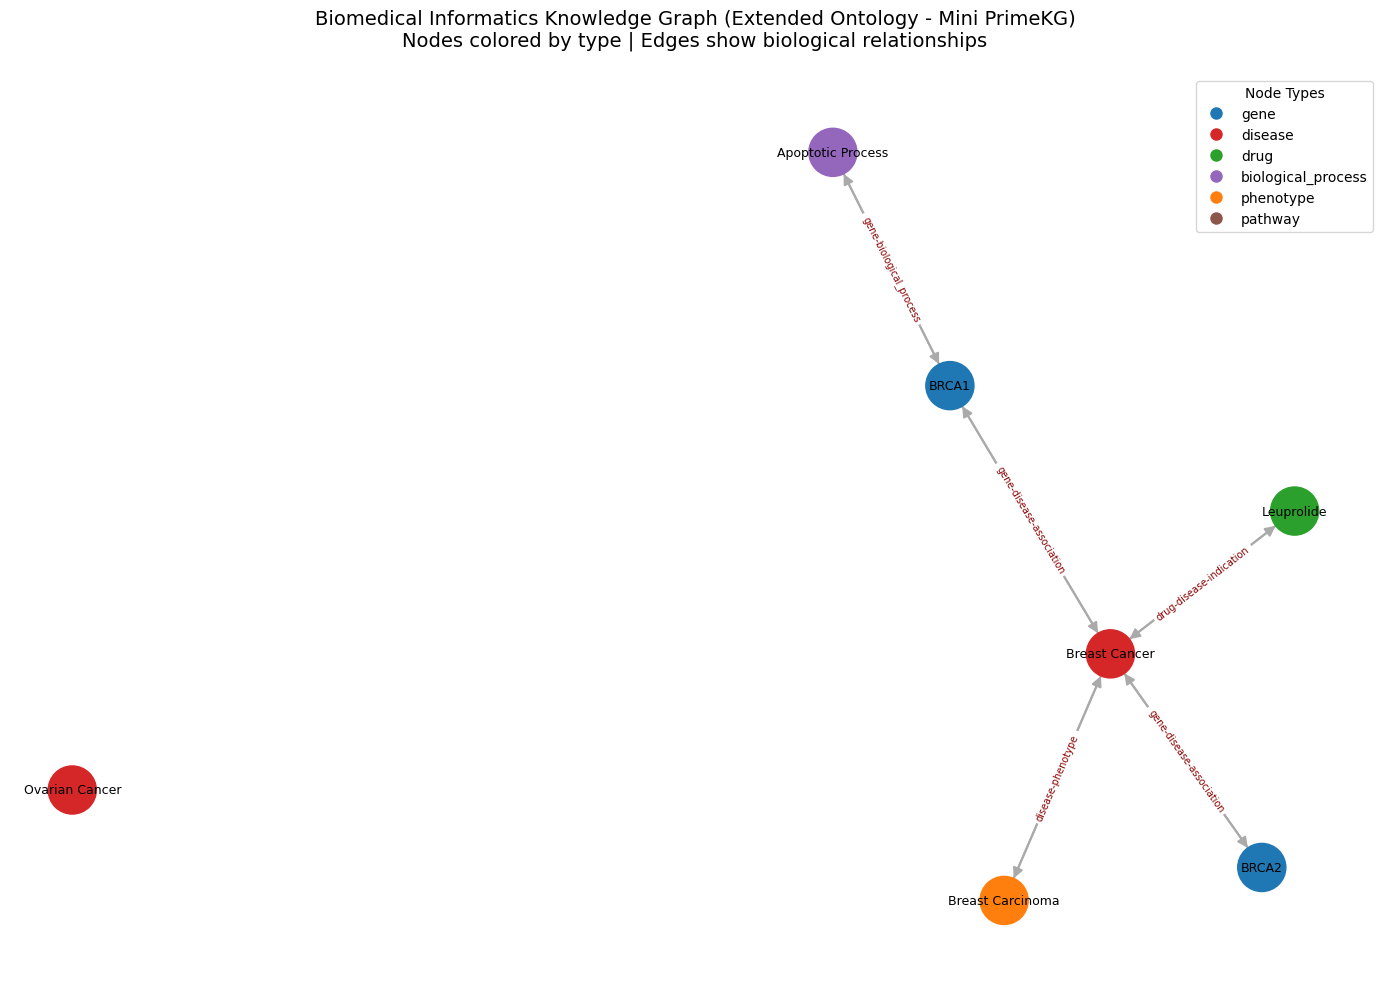

✅ Visualization saved as biomedical_kg_visualization.png


In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Extended Sample Data (add your real data here later)
nodes_data = [ ... ]   # (same as above – copy from the tool code if needed)
edges_data = [ ... ]   # (same as above)

# === Build nodes_df / edges_df / G (identical to previous code) ===
# ... (copy the full build section from my previous message)

# === Visualization (new part) ===
color_map = {
    "gene": "#1f77b4", "disease": "#d62728", "drug": "#2ca02c",
    "biological_process": "#9467bd", "phenotype": "#ff7f0e", "pathway": "#8c564b"
}

node_colors = [color_map.get(G.nodes[n]['node_type'], "#7f7f7f") for n in G.nodes()]
node_labels = {n: G.nodes[n]['name'] for n in G.nodes()}
pos = nx.spring_layout(G, seed=42, k=0.5)

plt.figure(figsize=(14, 10))
plt.title("Biomedical Informatics Knowledge Graph (Extended Ontology - Mini PrimeKG)\n"
          "Nodes colored by type | Edges show biological relationships", fontsize=14, pad=20)

nx.draw(G, pos, node_color=node_colors, node_size=1200, font_size=9,
        font_color="white", font_weight="bold", edge_color="#aaaaaa",
        width=1.5, arrows=True, arrowsize=15, with_labels=False)

nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9, font_color="black")

# Edge labels (relations)
edge_labels = {(u, v): d['relation'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, font_color="darkred")

# Legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=nt,
                              markerfacecolor=color_map.get(nt, "#7f7f7f"), markersize=10)
                   for nt in color_map]
plt.legend(handles=legend_elements, title="Node Types", loc="upper right", fontsize=10)

plt.axis("off")
plt.tight_layout()
plt.savefig("biomedical_kg_visualization.png", dpi=300, bbox_inches="tight")
plt.show()   # ← opens window on your machine
print("✅ Visualization saved as biomedical_kg_visualization.png")